Saving trafic2.0.avif to trafic2.0.avif


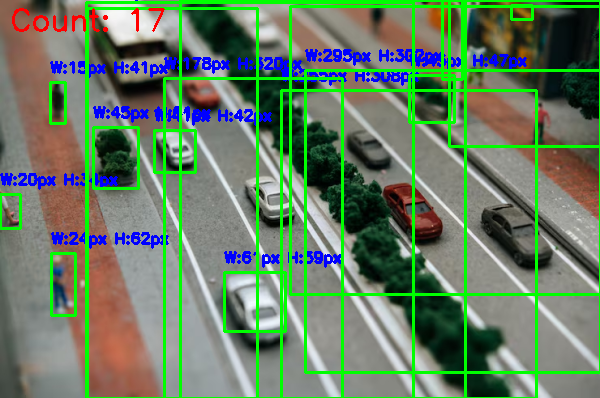

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:

# Import libraries
import cv2
import numpy as np
import imutils
from google.colab import files
from google.colab.patches import cv2_imshow

# Upload image
uploaded = files.upload()

# Get file name
image_path = list(uploaded.keys())[0]

# Load image
image = cv2.imread(image_path)
orig = image.copy()

# Resize image
image = imutils.resize(image, width=600)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Blur
blur = cv2.GaussianBlur(gray, (7, 7), 0)

# Edge detection
edged = cv2.Canny(blur, 50, 100)

# Morphological operations
edged = cv2.dilate(edged, None, iterations=1)
edged = cv2.erode(edged, None, iterations=1)

# Find contours
cnts = cv2.findContours(edged.copy(), cv2.RETR_EXTERNAL,
                        cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)

count = 0

# Loop through contours
for c in cnts:
    if cv2.contourArea(c) < 100:
        continue

    count += 1

    # Bounding box
    x, y, w, h = cv2.boundingRect(c)

    # Draw rectangle
    cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2)

    # Show measurement
    text = f"W:{w}px H:{h}px"
    cv2.putText(image, text, (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

# Display count
cv2.putText(image, f"Count: {count}", (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

# Show result
cv2_imshow(image)

# Save output
cv2.imwrite("output.png", image)

# Download output
files.download("output.png")